In [1]:
#Loading & Inspecting 

import pandas as pd

df = pd.read_csv("Dataset-Table 1-eight.csv")

df.head()

,FeedbackID,VisitDate,Channel,City,AttractionArea,VisitorType,VisitorFeedback,FeedbackCategory,VisitorRating,Unnamed: 9
0,TOU-001,2026-04-06,Google Review,Oshawa,Gift Shop,Tourist,"THE TICKET LINE AT CITYMUSEUM WAS VERY LONG, E...",Ticketing,3,NaN
1,TOU-002,2026-04-11,Email,Hamilton,Museum Exhibit,Local Visitor,"We liked the children's meal options, but the ...",Food_Service,3,NaN
2,TOU-003,2026-04-16,Kiosk Form,Ajax,Museum Exhibit,Student Group,The coffee shop closed before the evening even...,Food_Service,3,NaN
3,TOU-004,2026-04-21,Mobile App,Ottawa,Science Zone,Family,The coffee shop closed before the evening even...,Food_Service,3,NaN
4,TOU-005,2026-04-26,Exit Survey,Toronto,Gift Shop,Family,The accessible seating in the theatre worked w...,Accessibility,3,NaN


In [2]:
df.shape

(120, 10)

In [3]:
df.columns

Index(['FeedbackID', 'VisitDate', 'Channel', 'City', 'AttractionArea',
       'VisitorType', 'VisitorFeedback', 'FeedbackCategory', 'VisitorRating',
       'Unnamed: 9'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FeedbackID        120 non-null    object 
 1   VisitDate         120 non-null    object 
 2   Channel           120 non-null    object 
 3   City              120 non-null    object 
 4   AttractionArea    120 non-null    object 
 5   VisitorType       120 non-null    object 
 6   VisitorFeedback   120 non-null    object 
 7   FeedbackCategory  120 non-null    object 
 8   VisitorRating     120 non-null    int64  
 9   Unnamed: 9        0 non-null      float64
dtypes: float64(1), int64(1), object(8)
memory usage: 9.5+ KB


In [9]:
df_clean = df_clean.drop(columns=['Unnamed: 9'])

df_clean.isnull().sum()

FeedbackID          0
VisitDate           0
Channel             0
City                0
AttractionArea      0
VisitorType         0
VisitorFeedback     0
FeedbackCategory    0
VisitorRating       0
dtype: int64

In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   FeedbackID        120 non-null    object
 1   VisitDate         120 non-null    object
 2   Channel           120 non-null    object
 3   City              120 non-null    object
 4   AttractionArea    120 non-null    object
 5   VisitorType       120 non-null    object
 6   VisitorFeedback   120 non-null    object
 7   FeedbackCategory  120 non-null    object
 8   VisitorRating     120 non-null    int64 
dtypes: int64(1), object(8)
memory usage: 8.6+ KB


In [11]:
df_clean['FeedbackCategory'].value_counts()

FeedbackCategory
Ticketing             20
Food_Service          20
Accessibility         20
Exhibit_Experience    20
Staff_Guidance        20
Parking               20
Name: count, dtype: int64

In [15]:
#Text Preporcessing 

from nltk.corpus import stopwords
import string
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words("english"))

df_clean['clean_text'] = df_clean['VisitorFeedback'].apply(
    lambda x: ' '.join(
        w.lower()
        for w in word_tokenize(x)
        if w.isalpha() and w.lower() not in stop_words
    )
)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sheezatoor/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sheezatoor/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
df_clean[['VisitorFeedback', 'clean_text']].head()

,VisitorFeedback,clean_text
0,"THE TICKET LINE AT CITYMUSEUM WAS VERY LONG, E...",ticket line citymuseum long even though bought...
1,"We liked the children's meal options, but the ...",liked children meal options drink machine broken
2,The coffee shop closed before the evening even...,coffee shop closed evening event ended
3,The coffee shop closed before the evening even...,coffee shop closed evening event ended
4,The accessible seating in the theatre worked w...,accessible seating theatre worked well group


In [17]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df_clean['stemmed_text'] = df_clean['clean_text'].apply(
    lambda x: ' '.join(stemmer.stem(word) for word in x.split())
)



In [18]:
df_clean[['VisitorFeedback', 'stemmed_text']].head()

,VisitorFeedback,stemmed_text
0,"THE TICKET LINE AT CITYMUSEUM WAS VERY LONG, E...",ticket line citymuseum long even though bought...
1,"We liked the children's meal options, but the ...",like children meal option drink machin broken
2,The coffee shop closed before the evening even...,coffe shop close even event end
3,The coffee shop closed before the evening even...,coffe shop close even event end
4,The accessible seating in the theatre worked w...,access seat theatr work well group


In [19]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df_clean['lemmatized_text'] = df_clean['clean_text'].apply(
    lambda x: ' '.join(lemmatizer.lemmatize(word) for word in x.split())
)

In [20]:
df_clean[['VisitorFeedback', 'lemmatized_text']].head()

,VisitorFeedback,lemmatized_text
0,"THE TICKET LINE AT CITYMUSEUM WAS VERY LONG, E...",ticket line citymuseum long even though bought...
1,"We liked the children's meal options, but the ...",liked child meal option drink machine broken
2,The coffee shop closed before the evening even...,coffee shop closed evening event ended
3,The coffee shop closed before the evening even...,coffee shop closed evening event ended
4,The accessible seating in the theatre worked w...,accessible seating theatre worked well group


In [21]:
df_clean['preprocessed_text'] = df_clean['lemmatized_text']

df_clean[['VisitorFeedback', 'preprocessed_text']].head()

,VisitorFeedback,preprocessed_text
0,"THE TICKET LINE AT CITYMUSEUM WAS VERY LONG, E...",ticket line citymuseum long even though bought...
1,"We liked the children's meal options, but the ...",liked child meal option drink machine broken
2,The coffee shop closed before the evening even...,coffee shop closed evening event ended
3,The coffee shop closed before the evening even...,coffee shop closed evening event ended
4,The accessible seating in the theatre worked w...,accessible seating theatre worked well group


In [39]:
#Exploratory Text Analysis 

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

tokens = []

for text in df_clean['preprocessed_text'].dropna():
    tokens.extend(word_tokenize(text))

fdist = FreqDist(tokens)

print(fdist.most_common(10))

[('citymuseum', 33), ('ticket', 15), ('child', 15), ('staff', 15), ('parking', 15), ('line', 10), ('option', 10), ('machine', 10), ('broken', 10), ('theatre', 10)]


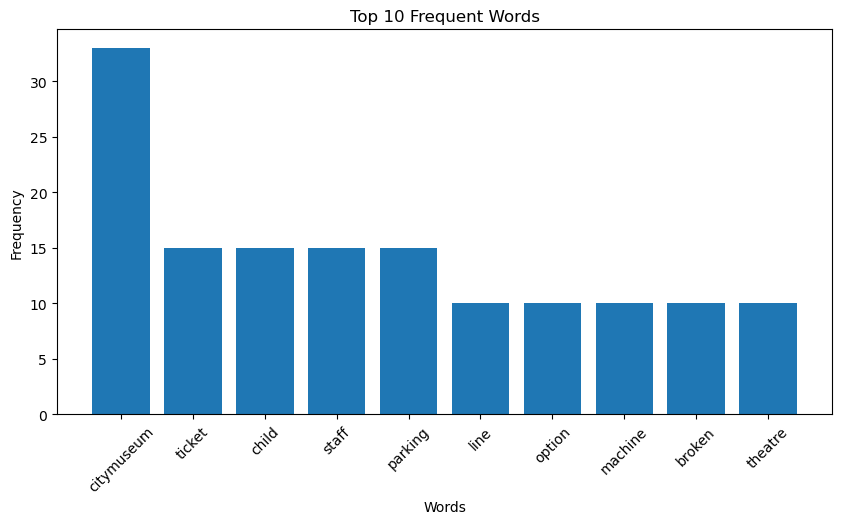

In [40]:
import matplotlib.pyplot as plt

top_words = fdist.most_common(10)

words = [w for w, _ in top_words]
counts = [c for _, c in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 10 Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [44]:
#POS Tagging and Named Entity Recognition


from nltk import pos_tag
from nltk.tokenize import word_tokenize

tokens = []

for text in df_clean['preprocessed_text'].dropna():
    tokens.extend(word_tokenize(text))

from nltk import pos_tag
import nltk

nltk.download("averaged_perceptron_tagger_eng")

samples = df_clean['preprocessed_text'].dropna().head(3)
for i, text in enumerate(samples, 1):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    
    print(f"\nExample {i}:")
    print(text)
    print(tags)


Example 1:
ticket line citymuseum long even though bought pass online citymuseum
[('ticket', 'NN'), ('line', 'NN'), ('citymuseum', 'NN'), ('long', 'RB'), ('even', 'RB'), ('though', 'IN'), ('bought', 'JJ'), ('pass', 'NN'), ('online', 'NN'), ('citymuseum', 'NN')]

Example 2:
liked child meal option drink machine broken
[('liked', 'VBN'), ('child', 'JJ'), ('meal', 'NN'), ('option', 'NN'), ('drink', 'VBP'), ('machine', 'NN'), ('broken', 'NN')]

Example 3:
coffee shop closed evening event ended
[('coffee', 'NN'), ('shop', 'NN'), ('closed', 'VBD'), ('evening', 'JJ'), ('event', 'NN'), ('ended', 'VBD')]


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/sheezatoor/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [48]:
from nltk import ne_chunk
import nltk

from nltk.tokenize import word_tokenize

tokens = []

for text in df_clean['preprocessed_text'].dropna():
    tokens.extend(word_tokenize(text))
    
nltk.download("maxent_ne_chunker_tab")
nltk.download("words")

samples = df_clean['preprocessed_text'].dropna().head(3)
for i, text in enumerate(samples, 1):
    tokens_for_ner = word_tokenize(text)
    pos_for_ner = pos_tag(tokens_for_ner)
    ner_tree = ne_chunk(pos_for_ner)
    
    print(f"\nNer Tree {i}:")
    print(text)
    print(ner_tree)


Ner Tree 1:
ticket line citymuseum long even though bought pass online citymuseum
(S
  ticket/NN
  line/NN
  citymuseum/NN
  long/RB
  even/RB
  though/IN
  bought/JJ
  pass/NN
  online/NN
  citymuseum/NN)

Ner Tree 2:
liked child meal option drink machine broken
(S
  liked/VBN
  child/JJ
  meal/NN
  option/NN
  drink/VBP
  machine/NN
  broken/NN)

Ner Tree 3:
coffee shop closed evening event ended
(S coffee/NN shop/NN closed/VBD evening/JJ event/NN ended/VBD)


[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /Users/sheezatoor/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     /Users/sheezatoor/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [52]:
#Bag of Words

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df_clean['preprocessed_text'])

print(X.shape)

import pandas as pd

bow_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bow_df.head()

(120, 131)


,accept,accessibility,accessible,afternoon,answered,aquarium,beautiful,bought,brampton,broken,...,vegetarian,visit,volunteer,website,well,wheelchair,whitby,worked,workshop,zone
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


In [59]:
#Build a Classification Model (Decision Tree)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

X = bow_df
y = df["FeedbackCategory"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

#Model Evaluation

y_pred = model.predict(X_test)

#Training Accuracy

train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

print("\nTraining Accuracy:")
print(train_accuracy)

#Testing Accuracy

test_accuracy = accuracy_score(y_test, y_pred)

print("\nTesting Accuracy:")
print(test_accuracy)

#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

#Classification Metrics: Accurancy, Precision, Recall, F1 Score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

#Classification Report 

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Training Accuracy:
0.5714285714285714

Testing Accuracy:
0.3333333333333333

Confusion Matrix:
[[ 0 10  0  0  0  0]
 [ 0  4  0  0  0  0]
 [ 0  2  2  0  0  0]
 [ 0  0  0  1  0  0]
 [ 0 11  0  0  0  0]
 [ 0  1  0  0  0  5]]

Accuracy: 0.3333333333333333
Precision: 0.3214285714285714
Recall: 0.3333333333333333
F1-Score: 0.28114478114478114

Classification Report:
                    precision    recall  f1-score   support

     Accessibility       0.00      0.00      0.00        10
Exhibit_Experience       0.14      1.00      0.25         4
      Food_Service       1.00      0.50      0.67         4
           Parking       1.00      1.00      1.00         1
    Staff_Guidance       0.00      0.00      0.00        11
         Ticketing       1.00      0.83      0.91         6

          accuracy                           0.33        36
         macro avg       0.52      0.56      0.47        36
      weighted avg       0.32      0.33      0.28        36



/Users/sheezatoor/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sheezatoor/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sheezatoor/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sheezatoor/anaconda